# Phase 6 — PM2.5-Based AQI and Hazardous-Condition Alerts

- **6A.** Inspect inputs and confirm the AQI standard
- **6B.** Build the reusable AQI conversion module
- **6C.** Enrich the forecast with hourly and rolling AQI
- **6D.** Generate alert flags and episodes
- **6E.** Validate with focused tests
- **6F.** Run pipeline and save artifacts

## **6A.** Validate Phase 5 inputs and AQI rules

Before implementing AQI conversion, this subphase confirms:

- a successful Phase 5 inference run exists
- the forecast contains exactly 72 ordered horizons
- all operational PM2.5 predictions are valid
- the forecast has one shared reference timestamp
- observed PM2.5 history is available for rolling 24-hour calculations
- the source pipeline run ID is preserved
- the current official EPA PM2.5 AQI rules are documented

No AQI values or alerts are generated in this subphase.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/riyan/Riyan/projects/pearls-aqi-predictor


### Discover saved Phase 5 inference runs

Each successful Phase 5 execution is stored in its own immutable run directory.

The newest valid run will be selected by inspecting its metadata and validation
report rather than relying only on the directory name.

In [3]:
PHASE_5_RUNS_DIR = (
    PROJECT_ROOT
    / "inference"
    / "runs"
)

if not PHASE_5_RUNS_DIR.exists():
    raise FileNotFoundError(
        "Phase 5 inference-runs directory was not found:\n"
        f"{PHASE_5_RUNS_DIR}"
    )

phase_5_run_directories = sorted(
    [
        path
        for path in PHASE_5_RUNS_DIR.iterdir()
        if path.is_dir()
    ],
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

print(
    "Phase 5 run directories found:",
    len(phase_5_run_directories),
)

for run_directory in phase_5_run_directories[:10]:
    print("-", run_directory.name)

Phase 5 run directories found: 2
- 20260728T150416Z_d93945f7
- 20260727T064244Z_ec8842b5


In [4]:
REQUIRED_PHASE_5_FILENAMES = {
    "forecast": "forecast.parquet",
    "pm25_input": "pm25_input.parquet",
    "weather_input": "weather_input.parquet",
    "feature_matrix": "feature_matrix.parquet",
    "metadata": "run_metadata.json",
    "validation_report": "validation_report.json",
}


phase_5_run_records = []

for run_directory in phase_5_run_directories:
    record: dict[str, Any] = {
        "run_id": run_directory.name,
        "run_directory": str(run_directory),
        "modified_time": pd.Timestamp(
            run_directory.stat().st_mtime,
            unit="s",
            tz="UTC",
        ),
    }

    for artifact_name, filename in (
        REQUIRED_PHASE_5_FILENAMES.items()
    ):
        artifact_path = run_directory / filename

        record[f"{artifact_name}_exists"] = (
            artifact_path.exists()
        )

        record[f"{artifact_name}_path"] = str(
            artifact_path
        )

    record["all_required_artifacts_exist"] = all(
        record[f"{artifact_name}_exists"]
        for artifact_name
        in REQUIRED_PHASE_5_FILENAMES
    )

    phase_5_run_records.append(record)


phase_5_run_summary_df = pd.DataFrame(
    phase_5_run_records
)

display(
    phase_5_run_summary_df[
        [
            "run_id",
            "modified_time",
            "all_required_artifacts_exist",
            *[
                f"{artifact_name}_exists"
                for artifact_name
                in REQUIRED_PHASE_5_FILENAMES
            ],
        ]
    ]
)

,run_id,modified_time,all_required_artifacts_exist,forecast_exists,pm25_input_exists,weather_input_exists,feature_matrix_exists,metadata_exists,validation_report_exists
0,20260728T150416Z_d93945f7,2026-07-28 15:04:18.628564119+00:00,True,True,True,True,True,True,True
1,20260727T064244Z_ec8842b5,2026-07-27 06:52:20.637994766+00:00,True,True,True,True,True,True,True


In [5]:
def read_json_file(
    path: Path,
) -> dict[str, Any]:
    """Read and validate one JSON object."""

    try:
        with path.open(
            "r",
            encoding="utf-8",
        ) as file:
            payload = json.load(file)
    except (OSError, json.JSONDecodeError) as exc:
        raise ValueError(
            f"Could not read valid JSON from: {path}"
        ) from exc

    if not isinstance(payload, dict):
        raise ValueError(
            f"Expected a JSON object in: {path}"
        )

    return payload

In [6]:
successful_phase_5_runs = []

for run_directory in phase_5_run_directories:
    validation_report_path = (
        run_directory
        / REQUIRED_PHASE_5_FILENAMES[
            "validation_report"
        ]
    )

    metadata_path = (
        run_directory
        / REQUIRED_PHASE_5_FILENAMES[
            "metadata"
        ]
    )

    required_paths_exist = all(
        (
            run_directory
            / filename
        ).exists()
        for filename
        in REQUIRED_PHASE_5_FILENAMES.values()
    )

    if not required_paths_exist:
        continue

    try:
        validation_payload = read_json_file(
            validation_report_path
        )

        metadata_payload = read_json_file(
            metadata_path
        )
    except ValueError:
        continue

    if validation_payload.get("status") != "PASSED":
        continue

    successful_phase_5_runs.append(
        {
            "run_directory": run_directory,
            "validation_report": (
                validation_payload
            ),
            "metadata": metadata_payload,
        }
    )


if not successful_phase_5_runs:
    raise RuntimeError(
        "No complete and successful Phase 5 "
        "inference run was found."
    )


selected_phase_5_run = (
    successful_phase_5_runs[0]
)

PHASE_5_RUN_DIR = (
    selected_phase_5_run["run_directory"]
)

phase_5_validation_report = (
    selected_phase_5_run[
        "validation_report"
    ]
)

phase_5_metadata = (
    selected_phase_5_run["metadata"]
)


print(
    "Selected Phase 5 run:",
    PHASE_5_RUN_DIR.name,
)

print(
    "Selected run directory:",
    PHASE_5_RUN_DIR,
)

Selected Phase 5 run: 20260728T150416Z_d93945f7
Selected run directory: /home/riyan/Riyan/projects/pearls-aqi-predictor/inference/runs/20260728T150416Z_d93945f7


In [7]:
PHASE_5_FORECAST_PATH = (
    PHASE_5_RUN_DIR
    / "forecast.parquet"
)

PHASE_5_PM25_INPUT_PATH = (
    PHASE_5_RUN_DIR
    / "pm25_input.parquet"
)

PHASE_5_WEATHER_INPUT_PATH = (
    PHASE_5_RUN_DIR
    / "weather_input.parquet"
)

PHASE_5_FEATURE_MATRIX_PATH = (
    PHASE_5_RUN_DIR
    / "feature_matrix.parquet"
)

PHASE_5_METADATA_PATH = (
    PHASE_5_RUN_DIR
    / "run_metadata.json"
)

PHASE_5_VALIDATION_REPORT_PATH = (
    PHASE_5_RUN_DIR
    / "validation_report.json"
)


phase_5_input_artifacts = {
    "forecast": PHASE_5_FORECAST_PATH,
    "PM2.5 input": PHASE_5_PM25_INPUT_PATH,
    "weather input": PHASE_5_WEATHER_INPUT_PATH,
    "feature matrix": PHASE_5_FEATURE_MATRIX_PATH,
    "metadata": PHASE_5_METADATA_PATH,
    "validation report": (
        PHASE_5_VALIDATION_REPORT_PATH
    ),
}


phase_5_artifact_status_df = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "exists": artifact_path.exists(),
            "size_bytes": (
                artifact_path.stat().st_size
                if artifact_path.exists()
                else None
            ),
            "path": str(artifact_path),
        }
        for artifact_name, artifact_path
        in phase_5_input_artifacts.items()
    ]
)

display(phase_5_artifact_status_df)

assert (
    phase_5_artifact_status_df["exists"]
    .all()
)

assert (
    phase_5_artifact_status_df["size_bytes"]
    .gt(0)
    .all()
)

print(
    "All required Phase 5 input artifacts exist."
)

,artifact,exists,size_bytes,path
0,forecast,True,10532,/home/riyan/Riyan/projects/pearls-aqi-predicto...
1,PM2.5 input,True,6940,/home/riyan/Riyan/projects/pearls-aqi-predicto...
2,weather input,True,9959,/home/riyan/Riyan/projects/pearls-aqi-predicto...
3,feature matrix,True,41724,/home/riyan/Riyan/projects/pearls-aqi-predicto...
4,metadata,True,1562,/home/riyan/Riyan/projects/pearls-aqi-predicto...
5,validation report,True,1104,/home/riyan/Riyan/projects/pearls-aqi-predicto...


All required Phase 5 input artifacts exist.


### Load the live forecast and observed PM2.5 history

The forecast provides 72 future operational PM2.5 predictions.

The PM2.5 input artifact contains the exact observed history used by the Phase 5
run. It will later be combined with the predicted values to construct trailing
24-hour windows.

The original artifacts are loaded without modification.

In [8]:
phase_5_forecast_df = pd.read_parquet(
    PHASE_5_FORECAST_PATH
)

phase_5_pm25_history_df = pd.read_parquet(
    PHASE_5_PM25_INPUT_PATH
)

phase_5_weather_input_df = pd.read_parquet(
    PHASE_5_WEATHER_INPUT_PATH
)

phase_5_feature_matrix_df = pd.read_parquet(
    PHASE_5_FEATURE_MATRIX_PATH
)


print(
    "Forecast shape:",
    phase_5_forecast_df.shape,
)

print(
    "Observed PM2.5 input shape:",
    phase_5_pm25_history_df.shape,
)

print(
    "Weather input shape:",
    phase_5_weather_input_df.shape,
)

print(
    "Feature matrix shape:",
    phase_5_feature_matrix_df.shape,
)

Forecast shape: (72, 12)
Observed PM2.5 input shape: (25, 10)
Weather input shape: (73, 11)
Feature matrix shape: (72, 58)


In [9]:
print("Forecast columns:")

for column in phase_5_forecast_df.columns:
    print("-", column)

Forecast columns:
- pipeline_run_id
- prediction_generated_at_utc
- reference_time
- target_time
- forecast_horizon_hours
- predicted_pm25_ug_m3_raw
- predicted_pm25_ug_m3
- prediction_was_clipped
- prediction_source
- location_name
- sensor_id
- selected_strategy


In [10]:
print("Observed PM2.5 columns:")

for column in phase_5_pm25_history_df.columns:
    print("-", column)

Observed PM2.5 columns:
- datetime_utc
- datetime_to_utc
- pm25_ug_m3
- pm25_ug_m3_raw
- pm25_zero_flag
- pm25_negative_flag
- has_flags
- parameter
- units
- sensor_id


In [11]:
display(
    phase_5_forecast_df.head()
)

display(
    phase_5_forecast_df.tail()
)

,pipeline_run_id,prediction_generated_at_utc,reference_time,target_time,forecast_horizon_hours,predicted_pm25_ug_m3_raw,predicted_pm25_ug_m3,prediction_was_clipped,prediction_source,location_name,sensor_id,selected_strategy
0,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-28 14:00:00+00:00,1,11.2,11.2,False,current_pm25_persistence,Zafar Memon DHA,13387396,hybrid_persistence_1_12_xgboost_shallower_13_72
1,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-28 15:00:00+00:00,2,11.2,11.2,False,current_pm25_persistence,Zafar Memon DHA,13387396,hybrid_persistence_1_12_xgboost_shallower_13_72
2,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-28 16:00:00+00:00,3,11.2,11.2,False,current_pm25_persistence,Zafar Memon DHA,13387396,hybrid_persistence_1_12_xgboost_shallower_13_72
3,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-28 17:00:00+00:00,4,11.2,11.2,False,current_pm25_persistence,Zafar Memon DHA,13387396,hybrid_persistence_1_12_xgboost_shallower_13_72
4,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-28 18:00:00+00:00,5,11.2,11.2,False,current_pm25_persistence,Zafar Memon DHA,13387396,hybrid_persistence_1_12_xgboost_shallower_13_72


,pipeline_run_id,prediction_generated_at_utc,reference_time,target_time,forecast_horizon_hours,predicted_pm25_ug_m3_raw,predicted_pm25_ug_m3,prediction_was_clipped,prediction_source,location_name,sensor_id,selected_strategy
67,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-31 09:00:00+00:00,68,12.216842,12.216842,False,xgboost_shallower,Zafar Memon DHA,13387396,hybrid_persistence_1_12_xgboost_shallower_13_72
68,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-31 10:00:00+00:00,69,12.216842,12.216842,False,xgboost_shallower,Zafar Memon DHA,13387396,hybrid_persistence_1_12_xgboost_shallower_13_72
69,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-31 11:00:00+00:00,70,11.666234,11.666234,False,xgboost_shallower,Zafar Memon DHA,13387396,hybrid_persistence_1_12_xgboost_shallower_13_72
70,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-31 12:00:00+00:00,71,11.756038,11.756038,False,xgboost_shallower,Zafar Memon DHA,13387396,hybrid_persistence_1_12_xgboost_shallower_13_72
71,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-31 13:00:00+00:00,72,12.552302,12.552302,False,xgboost_shallower,Zafar Memon DHA,13387396,hybrid_persistence_1_12_xgboost_shallower_13_72


In [12]:
REQUIRED_FORECAST_COLUMNS = [
    "pipeline_run_id",
    "prediction_generated_at_utc",
    "reference_time",
    "target_time",
    "forecast_horizon_hours",
    "predicted_pm25_ug_m3_raw",
    "predicted_pm25_ug_m3",
    "prediction_was_clipped",
    "prediction_source",
    "location_name",
    "sensor_id",
    "selected_strategy",
]


missing_forecast_columns = sorted(
    set(REQUIRED_FORECAST_COLUMNS)
    .difference(
        phase_5_forecast_df.columns
    )
)

print(
    "Missing required forecast columns:",
    missing_forecast_columns,
)

assert not missing_forecast_columns

Missing required forecast columns: []


### Validate the 72-hour forecast contract

Phase 6 must fail clearly if Phase 5 did not produce a valid forecast.

The checks below confirm:

- Phase 5 reported success
- exactly 72 forecast rows exist
- horizons are exactly 1 through 72
- target timestamps are unique, ordered, and hourly
- one reference timestamp is shared by every forecast row
- operational PM2.5 values are finite and non-negative
- no required forecast values are missing
- one pipeline run ID is preserved

In [13]:
phase_5_forecast_df = (
    phase_5_forecast_df
    .sort_values("forecast_horizon_hours")
    .reset_index(drop=True)
)


forecast_numeric_columns = [
    "forecast_horizon_hours",
    "predicted_pm25_ug_m3_raw",
    "predicted_pm25_ug_m3",
]

for column in forecast_numeric_columns:
    phase_5_forecast_df[column] = (
        pd.to_numeric(
            phase_5_forecast_df[column],
            errors="coerce",
        )
    )


forecast_validation_summary = {
    "phase_5_status": (
        phase_5_validation_report.get(
            "status"
        )
    ),
    "forecast_rows": len(
        phase_5_forecast_df
    ),
    "forecast_columns": len(
        phase_5_forecast_df.columns
    ),
    "first_horizon": (
        phase_5_forecast_df[
            "forecast_horizon_hours"
        ].min()
    ),
    "last_horizon": (
        phase_5_forecast_df[
            "forecast_horizon_hours"
        ].max()
    ),
    "unique_horizons": (
        phase_5_forecast_df[
            "forecast_horizon_hours"
        ].nunique()
    ),
    "unique_reference_times": (
        phase_5_forecast_df[
            "reference_time"
        ].nunique()
    ),
    "unique_target_times": (
        phase_5_forecast_df[
            "target_time"
        ].nunique()
    ),
    "duplicate_target_times": int(
        phase_5_forecast_df[
            "target_time"
        ].duplicated().sum()
    ),
    "missing_operational_pm25": int(
        phase_5_forecast_df[
            "predicted_pm25_ug_m3"
        ].isna().sum()
    ),
    "negative_operational_pm25": int(
        phase_5_forecast_df[
            "predicted_pm25_ug_m3"
        ].lt(0).sum()
    ),
    "infinite_operational_pm25": int(
        np.isinf(
            phase_5_forecast_df[
                "predicted_pm25_ug_m3"
            ].to_numpy(dtype=float)
        ).sum()
    ),
    "unique_pipeline_run_ids": (
        phase_5_forecast_df[
            "pipeline_run_id"
        ].nunique()
    ),
}

display(
    pd.Series(
        forecast_validation_summary,
        name="value",
    ).to_frame()
)

,value
phase_5_status,PASSED
forecast_rows,72
forecast_columns,12
first_horizon,1
last_horizon,72
unique_horizons,72
unique_reference_times,1
unique_target_times,72
duplicate_target_times,0
missing_operational_pm25,0


In [14]:
expected_forecast_horizons = list(
    range(1, 73)
)

expected_target_timeline = pd.date_range(
    start=(
        phase_5_forecast_df[
            "reference_time"
        ].iloc[0]
        + pd.Timedelta(hours=1)
    ),
    periods=72,
    freq="h",
    tz="UTC",
)


assert (
    phase_5_validation_report.get(
        "status"
    )
    == "PASSED"
)

assert len(phase_5_forecast_df) == 72

assert (
    phase_5_forecast_df[
        "forecast_horizon_hours"
    ]
    .astype(int)
    .tolist()
    == expected_forecast_horizons
)

assert (
    phase_5_forecast_df[
        "reference_time"
    ].nunique()
    == 1
)

assert (
    phase_5_forecast_df[
        "target_time"
    ].nunique()
    == 72
)

assert pd.DatetimeIndex(
    phase_5_forecast_df[
        "target_time"
    ]
).equals(expected_target_timeline)

assert (
    phase_5_forecast_df[
        "predicted_pm25_ug_m3"
    ]
    .isna()
    .sum()
    == 0
)

assert np.isfinite(
    phase_5_forecast_df[
        "predicted_pm25_ug_m3"
    ].to_numpy(dtype=float)
).all()

assert (
    phase_5_forecast_df[
        "predicted_pm25_ug_m3"
    ]
    .ge(0)
    .all()
)

assert (
    phase_5_forecast_df[
        "pipeline_run_id"
    ].nunique()
    == 1
)

print(
    "Phase 5 forecast contract validation passed."
)

Phase 5 forecast contract validation passed.


In [15]:
REQUIRED_PM25_HISTORY_COLUMNS = [
    "datetime_utc",
    "pm25_ug_m3",
]


missing_history_columns = sorted(
    set(REQUIRED_PM25_HISTORY_COLUMNS)
    .difference(
        phase_5_pm25_history_df.columns
    )
)

assert not missing_history_columns, (
    "Observed PM2.5 history is missing columns: "
    f"{missing_history_columns}"
)

In [16]:
phase_5_pm25_history_df[
    "pm25_ug_m3"
] = pd.to_numeric(
    phase_5_pm25_history_df[
        "pm25_ug_m3"
    ],
    errors="coerce",
)

phase_5_pm25_history_df = (
    phase_5_pm25_history_df
    .sort_values("datetime_utc")
    .reset_index(drop=True)
)


history_expected_timeline = pd.date_range(
    start=phase_5_pm25_history_df[
        "datetime_utc"
    ].min(),
    end=phase_5_pm25_history_df[
        "datetime_utc"
    ].max(),
    freq="h",
    tz="UTC",
)

missing_history_timestamps = (
    history_expected_timeline.difference(
        pd.DatetimeIndex(
            phase_5_pm25_history_df[
                "datetime_utc"
            ]
        )
    )
)


pm25_history_summary = {
    "rows": len(
        phase_5_pm25_history_df
    ),
    "first_timestamp": (
        phase_5_pm25_history_df[
            "datetime_utc"
        ].min()
    ),
    "last_timestamp": (
        phase_5_pm25_history_df[
            "datetime_utc"
        ].max()
    ),
    "reference_time": (
        phase_5_forecast_df[
            "reference_time"
        ].iloc[0]
    ),
    "duplicate_timestamps": int(
        phase_5_pm25_history_df[
            "datetime_utc"
        ].duplicated().sum()
    ),
    "missing_timestamps": len(
        missing_history_timestamps
    ),
    "missing_pm25_values": int(
        phase_5_pm25_history_df[
            "pm25_ug_m3"
        ].isna().sum()
    ),
    "invalid_non_positive_values": int(
        phase_5_pm25_history_df[
            "pm25_ug_m3"
        ].le(0).sum()
    ),
}

display(
    pd.Series(
        pm25_history_summary,
        name="value",
    ).to_frame()
)

,value
rows,25
first_timestamp,2026-07-27 13:00:00+00:00
last_timestamp,2026-07-28 13:00:00+00:00
reference_time,2026-07-28 13:00:00+00:00
duplicate_timestamps,0
missing_timestamps,0
missing_pm25_values,0
invalid_non_positive_values,0


In [17]:
selected_reference_time = (
    phase_5_forecast_df[
        "reference_time"
    ].iloc[0]
)

assert len(
    phase_5_pm25_history_df
) >= 24

assert (
    phase_5_pm25_history_df[
        "datetime_utc"
    ].max()
    == selected_reference_time
)

assert (
    phase_5_pm25_history_df[
        "datetime_utc"
    ].duplicated().sum()
    == 0
)

assert len(
    missing_history_timestamps
) == 0

assert (
    phase_5_pm25_history_df[
        "pm25_ug_m3"
    ].isna().sum()
    == 0
)

assert np.isfinite(
    phase_5_pm25_history_df[
        "pm25_ug_m3"
    ].to_numpy(dtype=float)
).all()

assert (
    phase_5_pm25_history_df[
        "pm25_ug_m3"
    ].gt(0).all()
)

print(
    "Observed PM2.5 history validation passed."
)

Observed PM2.5 history validation passed.


In [18]:
source_pipeline_run_id = str(
    phase_5_forecast_df[
        "pipeline_run_id"
    ].iloc[0]
)

metadata_pipeline_run_id = str(
    phase_5_metadata.get(
        "pipeline_run_id"
    )
)

selected_strategy = str(
    phase_5_forecast_df[
        "selected_strategy"
    ].iloc[0]
)


provenance_summary = {
    "source_pipeline_run_id": (
        source_pipeline_run_id
    ),
    "metadata_pipeline_run_id": (
        metadata_pipeline_run_id
    ),
    "run_ids_match": (
        source_pipeline_run_id
        == metadata_pipeline_run_id
    ),
    "selected_strategy": selected_strategy,
    "reference_time": (
        selected_reference_time
    ),
    "forecast_start": (
        phase_5_forecast_df[
            "target_time"
        ].min()
    ),
    "forecast_end": (
        phase_5_forecast_df[
            "target_time"
        ].max()
    ),
    "location_name": (
        phase_5_forecast_df[
            "location_name"
        ].iloc[0]
    ),
    "sensor_id": int(
        phase_5_forecast_df[
            "sensor_id"
        ].iloc[0]
    ),
}

display(
    pd.Series(
        provenance_summary,
        name="value",
    ).to_frame()
)

assert (
    source_pipeline_run_id
    == metadata_pipeline_run_id
)

,value
source_pipeline_run_id,20260728T150416Z_d93945f7
metadata_pipeline_run_id,20260728T150416Z_d93945f7
run_ids_match,True
selected_strategy,hybrid_persistence_1_12_xgboost_shallower_13_72
reference_time,2026-07-28 13:00:00+00:00
forecast_start,2026-07-28 14:00:00+00:00
forecast_end,2026-07-31 13:00:00+00:00
location_name,Zafar Memon DHA
sensor_id,13387396


### Official PM2.5 AQI calculation contract

Phase 6 will use the U.S. EPA Technical Assistance Document for the Reporting
of Daily Air Quality — the Air Quality Index, published in May 2026.

The implementation contract is:

1. preserve the original PM2.5 concentration
2. reject missing, infinite, or negative operational concentrations
3. truncate PM2.5 to one decimal place
4. locate the corresponding concentration and AQI breakpoint interval
5. apply piecewise linear interpolation
6. round the resulting AQI to the nearest integer
7. assign the official category and display color

The official PM2.5 AQI is based on a 24-hour concentration.

Therefore:

- `indicative_hourly_pm25_aqi` will describe a non-regulatory hourly
  interpretation
- `rolling_24h_pm25_aqi` will describe the AQI calculated from an exact trailing
  24-hour forecast concentration

In [19]:
AQI_STANDARD_METADATA = {
    "standard_name": (
        "United States Environmental "
        "Protection Agency Air Quality Index"
    ),
    "pollutant": "PM2.5",
    "concentration_unit": "µg/m³",
    "averaging_period": "24-hour",
    "source_organization": (
        "U.S. Environmental Protection Agency"
    ),
    "source_document": (
        "Technical Assistance Document for "
        "the Reporting of Daily Air Quality "
        "— the Air Quality Index (AQI)"
    ),
    "source_document_identifier": (
        "EPA-403/B-26-003"
    ),
    "source_document_version": "May 2026",
    "concentration_rule": (
        "Truncate PM2.5 to one decimal place "
        "before breakpoint lookup."
    ),
    "aqi_rule": (
        "Use piecewise linear interpolation "
        "and round the final index to the "
        "nearest integer."
    ),
    "hourly_interpretation_name": (
        "indicative_hourly_pm25_aqi"
    ),
    "rolling_interpretation_name": (
        "rolling_24h_pm25_aqi"
    ),
    "source_reference": (
        "Official EPA/AirNow Technical "
        "Assistance Document"
    ),
    "last_verified_date": (
        pd.Timestamp.now(tz="UTC")
        .date()
        .isoformat()
    ),
}

display(
    pd.Series(
        AQI_STANDARD_METADATA,
        name="value",
    ).to_frame()
)

,value
standard_name,United States Environmental Protection Agency ...
pollutant,PM2.5
concentration_unit,µg/m³
averaging_period,24-hour
source_organization,U.S. Environmental Protection Agency
source_document,Technical Assistance Document for the Reportin...
source_document_identifier,EPA-403/B-26-003
source_document_version,May 2026
concentration_rule,Truncate PM2.5 to one decimal place before bre...
aqi_rule,Use piecewise linear interpolation and round t...


In [20]:
official_pm25_breakpoint_reference_df = (
    pd.DataFrame(
        [
            {
                "pm25_low": 0.0,
                "pm25_high": 9.0,
                "aqi_low": 0,
                "aqi_high": 50,
                "category": "Good",
                "color_name": "Green",
                "severity_rank": 0,
            },
            {
                "pm25_low": 9.1,
                "pm25_high": 35.4,
                "aqi_low": 51,
                "aqi_high": 100,
                "category": "Moderate",
                "color_name": "Yellow",
                "severity_rank": 1,
            },
            {
                "pm25_low": 35.5,
                "pm25_high": 55.4,
                "aqi_low": 101,
                "aqi_high": 150,
                "category": (
                    "Unhealthy for Sensitive Groups"
                ),
                "color_name": "Orange",
                "severity_rank": 2,
            },
            {
                "pm25_low": 55.5,
                "pm25_high": 125.4,
                "aqi_low": 151,
                "aqi_high": 200,
                "category": "Unhealthy",
                "color_name": "Red",
                "severity_rank": 3,
            },
            {
                "pm25_low": 125.5,
                "pm25_high": 225.4,
                "aqi_low": 201,
                "aqi_high": 300,
                "category": "Very Unhealthy",
                "color_name": "Purple",
                "severity_rank": 4,
            },
            {
                "pm25_low": 225.5,
                "pm25_high": 325.4,
                "aqi_low": 301,
                "aqi_high": 500,
                "category": "Hazardous",
                "color_name": "Maroon",
                "severity_rank": 5,
            },
        ]
    )
)

display(
    official_pm25_breakpoint_reference_df
)

,pm25_low,pm25_high,aqi_low,aqi_high,category,color_name,severity_rank
0,0.0,9.0,0,50,Good,Green,0
1,9.1,35.4,51,100,Moderate,Yellow,1
2,35.5,55.4,101,150,Unhealthy for Sensitive Groups,Orange,2
3,55.5,125.4,151,200,Unhealthy,Red,3
4,125.5,225.4,201,300,Very Unhealthy,Purple,4
5,225.5,325.4,301,500,Hazardous,Maroon,5


In [21]:
official_aqi_color_reference_df = (
    pd.DataFrame(
        [
            {
                "category": "Good",
                "color_name": "Green",
                "rgb": (0, 228, 0),
                "hex": "#00E400",
            },
            {
                "category": "Moderate",
                "color_name": "Yellow",
                "rgb": (255, 255, 0),
                "hex": "#FFFF00",
            },
            {
                "category": (
                    "Unhealthy for Sensitive Groups"
                ),
                "color_name": "Orange",
                "rgb": (255, 126, 0),
                "hex": "#FF7E00",
            },
            {
                "category": "Unhealthy",
                "color_name": "Red",
                "rgb": (255, 0, 0),
                "hex": "#FF0000",
            },
            {
                "category": "Very Unhealthy",
                "color_name": "Purple",
                "rgb": (143, 63, 151),
                "hex": "#8F3F97",
            },
            {
                "category": "Hazardous",
                "color_name": "Maroon",
                "rgb": (126, 0, 35),
                "hex": "#7E0023",
            },
        ]
    )
)

display(
    official_aqi_color_reference_df
)

,category,color_name,rgb,hex
0,Good,Green,"(0, 228, 0)",#00E400
1,Moderate,Yellow,"(255, 255, 0)",#FFFF00
2,Unhealthy for Sensitive Groups,Orange,"(255, 126, 0)",#FF7E00
3,Unhealthy,Red,"(255, 0, 0)",#FF0000
4,Very Unhealthy,Purple,"(143, 63, 151)",#8F3F97
5,Hazardous,Maroon,"(126, 0, 35)",#7E0023


### Inspect rolling-window input coverage

The combined timeline will contain:

- observed PM2.5 values through the selected reference hour
- predicted PM2.5 values after the reference hour

For each forecast target, the later rolling implementation will require exactly
24 hourly timestamps from `target_time - 23 hours` through `target_time`.

This check confirms whether the saved Phase 5 inputs appear capable of
supporting those windows.

In [22]:
observed_timeline_df = (
    phase_5_pm25_history_df[
        [
            "datetime_utc",
            "pm25_ug_m3",
        ]
    ]
    .rename(
        columns={
            "datetime_utc": "timestamp_utc",
            "pm25_ug_m3": "pm25_ug_m3",
        }
    )
    .assign(source="observed")
)


predicted_timeline_df = (
    phase_5_forecast_df[
        [
            "target_time",
            "predicted_pm25_ug_m3",
        ]
    ]
    .rename(
        columns={
            "target_time": "timestamp_utc",
            "predicted_pm25_ug_m3": (
                "pm25_ug_m3"
            ),
        }
    )
    .assign(source="predicted")
)


combined_pm25_timeline_preview_df = (
    pd.concat(
        [
            observed_timeline_df,
            predicted_timeline_df,
        ],
        ignore_index=True,
    )
    .sort_values("timestamp_utc")
    .drop_duplicates(
        subset=["timestamp_utc"],
        keep="last",
    )
    .reset_index(drop=True)
)

print(
    "Combined PM2.5 timeline rows:",
    len(combined_pm25_timeline_preview_df),
)

print(
    "Combined timeline start:",
    combined_pm25_timeline_preview_df[
        "timestamp_utc"
    ].min(),
)

print(
    "Combined timeline end:",
    combined_pm25_timeline_preview_df[
        "timestamp_utc"
    ].max(),
)

Combined PM2.5 timeline rows: 97
Combined timeline start: 2026-07-27 13:00:00+00:00
Combined timeline end: 2026-07-31 13:00:00+00:00


In [23]:
combined_timestamp_index = pd.DatetimeIndex(
    combined_pm25_timeline_preview_df[
        "timestamp_utc"
    ]
)


rolling_readiness_records = []

for forecast_row in (
    phase_5_forecast_df.itertuples(
        index=False
    )
):
    target_time = forecast_row.target_time

    required_window = pd.date_range(
        end=target_time,
        periods=24,
        freq="h",
        tz="UTC",
    )

    missing_window_timestamps = (
        required_window.difference(
            combined_timestamp_index
        )
    )

    rolling_readiness_records.append(
        {
            "forecast_horizon_hours": int(
                forecast_row
                .forecast_horizon_hours
            ),
            "target_time": target_time,
            "required_hours": 24,
            "missing_hours": len(
                missing_window_timestamps
            ),
            "window_complete": (
                len(
                    missing_window_timestamps
                )
                == 0
            ),
        }
    )


rolling_input_readiness_df = pd.DataFrame(
    rolling_readiness_records
)

display(
    rolling_input_readiness_df.head()
)

display(
    rolling_input_readiness_df.tail()
)

,forecast_horizon_hours,target_time,required_hours,missing_hours,window_complete
0,1,2026-07-28 14:00:00+00:00,24,0,True
1,2,2026-07-28 15:00:00+00:00,24,0,True
2,3,2026-07-28 16:00:00+00:00,24,0,True
3,4,2026-07-28 17:00:00+00:00,24,0,True
4,5,2026-07-28 18:00:00+00:00,24,0,True


,forecast_horizon_hours,target_time,required_hours,missing_hours,window_complete
67,68,2026-07-31 09:00:00+00:00,24,0,True
68,69,2026-07-31 10:00:00+00:00,24,0,True
69,70,2026-07-31 11:00:00+00:00,24,0,True
70,71,2026-07-31 12:00:00+00:00,24,0,True
71,72,2026-07-31 13:00:00+00:00,24,0,True


In [24]:
rolling_input_summary = {
    "forecast_rows": len(
        rolling_input_readiness_df
    ),
    "complete_rolling_windows": int(
        rolling_input_readiness_df[
            "window_complete"
        ].sum()
    ),
    "incomplete_rolling_windows": int(
        (
            ~rolling_input_readiness_df[
                "window_complete"
            ]
        ).sum()
    ),
    "maximum_missing_hours": int(
        rolling_input_readiness_df[
            "missing_hours"
        ].max()
    ),
}

display(
    pd.Series(
        rolling_input_summary,
        name="value",
    ).to_frame()
)

,value
forecast_rows,72
complete_rolling_windows,72
incomplete_rolling_windows,0
maximum_missing_hours,0


## **6B.** Implement the PM2.5-to-AQI converter

This subphase creates the reusable AQI conversion layer.

For each valid PM2.5 concentration, the converter:

1. preserves the original concentration
2. truncates the value to one decimal place
3. finds the matching EPA PM2.5 breakpoint
4. applies linear interpolation
5. rounds the calculated AQI to the nearest integer
6. assigns its category, color, and severity
7. identifies values that are Beyond the AQI

Missing values may remain missing when converting a dataset. Negative or
infinite operational concentrations are rejected.

Rolling 24-hour averages and forecast alerts are not generated yet.

In [25]:
import importlib

import app.aqi.config
import app.aqi.pm25_aqi

importlib.reload(app.aqi.config)
importlib.reload(app.aqi.pm25_aqi)

from app.aqi.config import (
    AQI_STANDARD_NAME,
    AQI_STANDARD_VERSION,
    PM25_AQI_BREAKPOINTS,
)

from app.aqi.pm25_aqi import (
    PM25AQIConversionError,
    calculate_pm25_aqi,
    convert_pm25_series_to_aqi,
    truncate_pm25,
)

In [26]:
centralized_breakpoint_df = pd.DataFrame(
    [
        {
            "pm25_low": breakpoint.concentration_low,
            "pm25_high": breakpoint.concentration_high,
            "aqi_low": breakpoint.aqi_low,
            "aqi_high": breakpoint.aqi_high,
            "category": breakpoint.category,
            "color_name": breakpoint.color_name,
            "color_hex": breakpoint.color_hex,
            "severity_rank": breakpoint.severity_rank,
        }
        for breakpoint in PM25_AQI_BREAKPOINTS
    ]
)

print("AQI standard:", AQI_STANDARD_NAME)
print("AQI standard version:", AQI_STANDARD_VERSION)

display(centralized_breakpoint_df)

AQI standard: U.S. EPA PM2.5 AQI
AQI standard version: May 2026


,pm25_low,pm25_high,aqi_low,aqi_high,category,color_name,color_hex,severity_rank
0,0.0,9.0,0,50,Good,Green,#00E400,0
1,9.1,35.4,51,100,Moderate,Yellow,#FFFF00,1
2,35.5,55.4,101,150,Unhealthy for Sensitive Groups,Orange,#FF7E00,2
3,55.5,125.4,151,200,Unhealthy,Red,#FF0000,3
4,125.5,225.4,201,300,Very Unhealthy,Purple,#8F3F97,4
5,225.5,325.4,301,500,Hazardous,Maroon,#7E0023,5


In [27]:
pd.testing.assert_frame_equal(
    official_pm25_breakpoint_reference_df[
        [
            "pm25_low",
            "pm25_high",
            "aqi_low",
            "aqi_high",
            "category",
            "color_name",
            "severity_rank",
        ]
    ].reset_index(drop=True),
    centralized_breakpoint_df[
        [
            "pm25_low",
            "pm25_high",
            "aqi_low",
            "aqi_high",
            "category",
            "color_name",
            "severity_rank",
        ]
    ].reset_index(drop=True),
    check_dtype=False,
)

print(
    "Centralized AQI breakpoints match "
    "the Phase 6A reference."
)

Centralized AQI breakpoints match the Phase 6A reference.


### Validate concentration truncation

PM2.5 is truncated rather than rounded.

Examples:

- `9.09` becomes `9.0`
- `9.19` becomes `9.1`
- `35.49` becomes `35.4`
- `35.59` becomes `35.5`

This behavior is important at category boundaries.

In [28]:
truncation_examples = {
    0.0: truncate_pm25(0.0),
    9.09: truncate_pm25(9.09),
    9.19: truncate_pm25(9.19),
    35.49: truncate_pm25(35.49),
    35.59: truncate_pm25(35.59),
    125.49: truncate_pm25(125.49),
}

display(
    pd.Series(
        truncation_examples,
        name="truncated_value",
    ).to_frame()
)

assert truncate_pm25(9.09) == 9.0
assert truncate_pm25(9.19) == 9.1
assert truncate_pm25(35.49) == 35.4
assert truncate_pm25(35.59) == 35.5

print("PM2.5 truncation validation passed.")

,truncated_value
0.00,0.0
9.09,9.0
9.19,9.1
35.49,35.4
35.59,35.5
125.49,125.4


PM2.5 truncation validation passed.


In [29]:
boundary_test_values = [
    0.0,
    9.0,
    9.1,
    35.4,
    35.5,
    55.4,
    55.5,
    125.4,
    125.5,
    225.4,
    225.5,
    325.4,
    325.5,
]

boundary_result_df = pd.DataFrame(
    [
        calculate_pm25_aqi(value).to_dict()
        for value in boundary_test_values
    ]
)

display(boundary_result_df)

,original_pm25_ug_m3,truncated_pm25_ug_m3,aqi,category,color_name,color_hex,severity_rank,is_beyond_aqi
0,0.0,0.0,0,Good,Green,#00E400,0,False
1,9.0,9.0,50,Good,Green,#00E400,0,False
2,9.1,9.1,51,Moderate,Yellow,#FFFF00,1,False
3,35.4,35.4,100,Moderate,Yellow,#FFFF00,1,False
4,35.5,35.5,101,Unhealthy for Sensitive Groups,Orange,#FF7E00,2,False
5,55.4,55.4,150,Unhealthy for Sensitive Groups,Orange,#FF7E00,2,False
6,55.5,55.5,151,Unhealthy,Red,#FF0000,3,False
7,125.4,125.4,200,Unhealthy,Red,#FF0000,3,False
8,125.5,125.5,201,Very Unhealthy,Purple,#8F3F97,4,False
9,225.4,225.4,300,Very Unhealthy,Purple,#8F3F97,4,False


In [30]:
expected_boundary_results = {
    0.0: (0, "Good"),
    9.0: (50, "Good"),
    9.1: (51, "Moderate"),
    35.4: (100, "Moderate"),
    35.5: (
        101,
        "Unhealthy for Sensitive Groups",
    ),
    55.4: (
        150,
        "Unhealthy for Sensitive Groups",
    ),
    55.5: (151, "Unhealthy"),
    125.4: (200, "Unhealthy"),
    125.5: (201, "Very Unhealthy"),
    225.4: (300, "Very Unhealthy"),
    225.5: (301, "Hazardous"),
    325.4: (500, "Hazardous"),
}


for concentration, (
    expected_aqi,
    expected_category,
) in expected_boundary_results.items():
    result = calculate_pm25_aqi(
        concentration
    )

    assert result.aqi == expected_aqi
    assert result.category == expected_category


print(
    "AQI breakpoint-boundary validation passed."
)

AQI breakpoint-boundary validation passed.


In [31]:
invalid_input_results = {}

for value in [-1.0, np.inf, -np.inf]:
    try:
        calculate_pm25_aqi(value)
    except PM25AQIConversionError as exc:
        invalid_input_results[str(value)] = str(exc)

display(
    pd.Series(
        invalid_input_results,
        name="error",
    ).to_frame()
)

assert len(invalid_input_results) == 3

print("Invalid AQI inputs are rejected correctly.")

,error
-1.0,PM2.5 concentration cannot be negative.
inf,PM2.5 concentration must be finite.
-inf,PM2.5 concentration must be finite.


Invalid AQI inputs are rejected correctly.


In [32]:
missing_value_example = pd.Series(
    [8.0, np.nan, 12.0],
    name="pm25",
)

missing_value_conversion_df = (
    convert_pm25_series_to_aqi(
        missing_value_example
    )
)

display(missing_value_conversion_df)

assert missing_value_conversion_df[
    "aqi"
].isna().sum() == 1

,pm25_ug_m3_original,pm25_ug_m3_truncated,aqi,aqi_category,aqi_color_name,aqi_color_hex,aqi_severity_rank,is_beyond_aqi
0,8.0,8.0,44,Good,Green,#00E400,0,False
1,NaN,NaN,<NA>,NaN,NaN,NaN,<NA>,<NA>
2,12.0,12.0,56,Moderate,Yellow,#FFFF00,1,False


In [33]:
phase_5_hourly_aqi_preview_df = (
    convert_pm25_series_to_aqi(
        phase_5_forecast_df[
            "predicted_pm25_ug_m3"
        ]
    )
)

print(
    "Hourly AQI preview shape:",
    phase_5_hourly_aqi_preview_df.shape,
)

display(
    pd.concat(
        [
            phase_5_forecast_df[
                [
                    "target_time",
                    "forecast_horizon_hours",
                    "predicted_pm25_ug_m3",
                ]
            ].reset_index(drop=True),
            phase_5_hourly_aqi_preview_df[
                [
                    "pm25_ug_m3_truncated",
                    "aqi",
                    "aqi_category",
                    "aqi_color_name",
                ]
            ].reset_index(drop=True),
        ],
        axis=1,
    ).head(15)
)

Hourly AQI preview shape: (72, 8)


,target_time,forecast_horizon_hours,predicted_pm25_ug_m3,pm25_ug_m3_truncated,aqi,aqi_category,aqi_color_name
0,2026-07-28 14:00:00+00:00,1,11.200000,11.2,55,Moderate,Yellow
1,2026-07-28 15:00:00+00:00,2,11.200000,11.2,55,Moderate,Yellow
2,2026-07-28 16:00:00+00:00,3,11.200000,11.2,55,Moderate,Yellow
3,2026-07-28 17:00:00+00:00,4,11.200000,11.2,55,Moderate,Yellow
4,2026-07-28 18:00:00+00:00,5,11.200000,11.2,55,Moderate,Yellow
5,2026-07-28 19:00:00+00:00,6,11.200000,11.2,55,Moderate,Yellow
6,2026-07-28 20:00:00+00:00,7,11.200000,11.2,55,Moderate,Yellow
7,2026-07-28 21:00:00+00:00,8,11.200000,11.2,55,Moderate,Yellow
8,2026-07-28 22:00:00+00:00,9,11.200000,11.2,55,Moderate,Yellow
9,2026-07-28 23:00:00+00:00,10,11.200000,11.2,55,Moderate,Yellow


In [34]:
monotonic_test_concentrations = pd.Series(
    np.arange(
        0.0,
        325.5,
        0.1,
    )
)

monotonic_test_results = (
    convert_pm25_series_to_aqi(
        monotonic_test_concentrations
    )
)

aqi_differences = (
    monotonic_test_results[
        "aqi"
    ]
    .astype(float)
    .diff()
    .dropna()
)

assert aqi_differences.ge(0).all()

print(
    "PM2.5-to-AQI conversion is monotonic."
)

PM2.5-to-AQI conversion is monotonic.


## **6C.** Add hourly and rolling 24-hour AQI

The validated Phase 5 forecast is now enriched with two AQI interpretations.

### Indicative hourly AQI

Each individual predicted PM2.5 value is converted using the EPA breakpoint
equation.

This supports hourly forecast presentation, but it is clearly labeled
indicative because official PM2.5 AQI is based on a 24-hour concentration.

### Rolling 24-hour AQI

For every forecast target hour, an exact trailing 24-hour PM2.5 window is
constructed from:

- observed PM2.5 through the reference timestamp
- forecast PM2.5 after the reference timestamp

Each window covers `target_time - 23 hours` through `target_time`.

All 24 timestamps must exist. Missing hours are not interpolated, forward-filled,
or replaced.

In [35]:
import importlib

import app.aqi.forecast_enrichment

importlib.reload(
    app.aqi.forecast_enrichment
)

from app.aqi.forecast_enrichment import (
    AQIForecastEnrichmentError,
    enrich_forecast_with_aqi,
)

In [36]:
phase_6_enriched_forecast_df = (
    enrich_forecast_with_aqi(
        forecast_df=phase_5_forecast_df,
        observed_pm25_df=(
            phase_5_pm25_history_df
        ),
    )
)

print(
    "AQI-enriched forecast shape:",
    phase_6_enriched_forecast_df.shape,
)

display(
    phase_6_enriched_forecast_df.head()
)

display(
    phase_6_enriched_forecast_df.tail()
)

AQI-enriched forecast shape: (72, 32)


,pipeline_run_id,prediction_generated_at_utc,reference_time,target_time,forecast_horizon_hours,predicted_pm25_ug_m3_raw,predicted_pm25_ug_m3,prediction_was_clipped,prediction_source,location_name,...,rolling_24h_missing_hours,rolling_observed_hour_count,rolling_predicted_hour_count,rolling_24h_pm25_ug_m3_truncated,rolling_24h_pm25_aqi,rolling_24h_aqi_category,rolling_24h_aqi_color_name,rolling_24h_aqi_color_hex,rolling_24h_aqi_severity_rank,rolling_24h_is_beyond_aqi
0,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-28 14:00:00+00:00,1,11.2,11.2,False,current_pm25_persistence,Zafar Memon DHA,...,0,23,1,8.6,48,Good,Green,#00E400,0,False
1,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-28 15:00:00+00:00,2,11.2,11.2,False,current_pm25_persistence,Zafar Memon DHA,...,0,22,2,8.7,48,Good,Green,#00E400,0,False
2,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-28 16:00:00+00:00,3,11.2,11.2,False,current_pm25_persistence,Zafar Memon DHA,...,0,21,3,8.8,49,Good,Green,#00E400,0,False
3,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-28 17:00:00+00:00,4,11.2,11.2,False,current_pm25_persistence,Zafar Memon DHA,...,0,20,4,8.9,49,Good,Green,#00E400,0,False
4,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-28 18:00:00+00:00,5,11.2,11.2,False,current_pm25_persistence,Zafar Memon DHA,...,0,19,5,8.9,49,Good,Green,#00E400,0,False


,pipeline_run_id,prediction_generated_at_utc,reference_time,target_time,forecast_horizon_hours,predicted_pm25_ug_m3_raw,predicted_pm25_ug_m3,prediction_was_clipped,prediction_source,location_name,...,rolling_24h_missing_hours,rolling_observed_hour_count,rolling_predicted_hour_count,rolling_24h_pm25_ug_m3_truncated,rolling_24h_pm25_aqi,rolling_24h_aqi_category,rolling_24h_aqi_color_name,rolling_24h_aqi_color_hex,rolling_24h_aqi_severity_rank,rolling_24h_is_beyond_aqi
67,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-31 09:00:00+00:00,68,12.216842,12.216842,False,xgboost_shallower,Zafar Memon DHA,...,0,0,24,12.9,58,Moderate,Yellow,#FFFF00,1,False
68,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-31 10:00:00+00:00,69,12.216842,12.216842,False,xgboost_shallower,Zafar Memon DHA,...,0,0,24,12.9,58,Moderate,Yellow,#FFFF00,1,False
69,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-31 11:00:00+00:00,70,11.666234,11.666234,False,xgboost_shallower,Zafar Memon DHA,...,0,0,24,13.0,58,Moderate,Yellow,#FFFF00,1,False
70,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-31 12:00:00+00:00,71,11.756038,11.756038,False,xgboost_shallower,Zafar Memon DHA,...,0,0,24,13.0,58,Moderate,Yellow,#FFFF00,1,False
71,20260728T150416Z_d93945f7,2026-07-28 15:04:16.795612+00:00,2026-07-28 13:00:00+00:00,2026-07-31 13:00:00+00:00,72,12.552302,12.552302,False,xgboost_shallower,Zafar Memon DHA,...,0,0,24,13.0,58,Moderate,Yellow,#FFFF00,1,False


In [37]:
aqi_preview_columns = [
    "target_time",
    "forecast_horizon_hours",
    "predicted_pm25_ug_m3",
    "predicted_pm25_ug_m3_truncated",
    "indicative_hourly_pm25_aqi",
    "indicative_hourly_aqi_category",
    "rolling_24h_pm25_ug_m3",
    "rolling_24h_pm25_aqi",
    "rolling_24h_aqi_category",
    "rolling_24h_pm25_is_complete",
    "rolling_observed_hour_count",
    "rolling_predicted_hour_count",
]

display(
    phase_6_enriched_forecast_df[
        aqi_preview_columns
    ].head(15)
)

display(
    phase_6_enriched_forecast_df[
        aqi_preview_columns
    ].tail(10)
)

,target_time,forecast_horizon_hours,predicted_pm25_ug_m3,predicted_pm25_ug_m3_truncated,indicative_hourly_pm25_aqi,indicative_hourly_aqi_category,rolling_24h_pm25_ug_m3,rolling_24h_pm25_aqi,rolling_24h_aqi_category,rolling_24h_pm25_is_complete,rolling_observed_hour_count,rolling_predicted_hour_count
0,2026-07-28 14:00:00+00:00,1,11.200000,11.2,55,Moderate,8.637500,48,Good,True,23,1
1,2026-07-28 15:00:00+00:00,2,11.200000,11.2,55,Moderate,8.716667,48,Good,True,22,2
2,2026-07-28 16:00:00+00:00,3,11.200000,11.2,55,Moderate,8.854167,49,Good,True,21,3
3,2026-07-28 17:00:00+00:00,4,11.200000,11.2,55,Moderate,8.954167,49,Good,True,20,4
4,2026-07-28 18:00:00+00:00,5,11.200000,11.2,55,Moderate,8.941667,49,Good,True,19,5
5,2026-07-28 19:00:00+00:00,6,11.200000,11.2,55,Moderate,9.058333,50,Good,True,18,6
6,2026-07-28 20:00:00+00:00,7,11.200000,11.2,55,Moderate,9.241667,51,Moderate,True,17,7
7,2026-07-28 21:00:00+00:00,8,11.200000,11.2,55,Moderate,9.429167,52,Moderate,True,16,8
8,2026-07-28 22:00:00+00:00,9,11.200000,11.2,55,Moderate,9.616667,52,Moderate,True,15,9
9,2026-07-28 23:00:00+00:00,10,11.200000,11.2,55,Moderate,9.779167,52,Moderate,True,14,10


,target_time,forecast_horizon_hours,predicted_pm25_ug_m3,predicted_pm25_ug_m3_truncated,indicative_hourly_pm25_aqi,indicative_hourly_aqi_category,rolling_24h_pm25_ug_m3,rolling_24h_pm25_aqi,rolling_24h_aqi_category,rolling_24h_pm25_is_complete,rolling_observed_hour_count,rolling_predicted_hour_count
62,2026-07-31 04:00:00+00:00,63,13.833826,13.8,60,Moderate,12.576109,57,Moderate,True,0,24
63,2026-07-31 05:00:00+00:00,64,14.082102,14.0,60,Moderate,12.661358,58,Moderate,True,0,24
64,2026-07-31 06:00:00+00:00,65,13.054831,13.0,58,Moderate,12.775281,58,Moderate,True,0,24
65,2026-07-31 07:00:00+00:00,66,12.011154,12.0,56,Moderate,12.804009,58,Moderate,True,0,24
66,2026-07-31 08:00:00+00:00,67,12.056466,12.0,56,Moderate,12.849860,58,Moderate,True,0,24
67,2026-07-31 09:00:00+00:00,68,12.216842,12.2,57,Moderate,12.910463,58,Moderate,True,0,24
68,2026-07-31 10:00:00+00:00,69,12.216842,12.2,57,Moderate,12.971066,58,Moderate,True,0,24
69,2026-07-31 11:00:00+00:00,70,11.666234,11.6,56,Moderate,13.011290,58,Moderate,True,0,24
70,2026-07-31 12:00:00+00:00,71,11.756038,11.7,56,Moderate,13.042638,58,Moderate,True,0,24
71,2026-07-31 13:00:00+00:00,72,12.552302,12.5,57,Moderate,13.072193,58,Moderate,True,0,24


In [38]:
indicative_hourly_aqi_summary = {
    "rows": len(
        phase_6_enriched_forecast_df
    ),
    "minimum_aqi": int(
        phase_6_enriched_forecast_df[
            "indicative_hourly_pm25_aqi"
        ].min()
    ),
    "maximum_aqi": int(
        phase_6_enriched_forecast_df[
            "indicative_hourly_pm25_aqi"
        ].max()
    ),
    "missing_aqi_values": int(
        phase_6_enriched_forecast_df[
            "indicative_hourly_pm25_aqi"
        ].isna().sum()
    ),
    "beyond_aqi_rows": int(
        phase_6_enriched_forecast_df[
            "indicative_hourly_is_beyond_aqi"
        ].fillna(False).sum()
    ),
}

display(
    pd.Series(
        indicative_hourly_aqi_summary,
        name="value",
    ).to_frame()
)

,value
rows,72
minimum_aqi,52
maximum_aqi,63
missing_aqi_values,0
beyond_aqi_rows,0


In [39]:
rolling_window_summary = {
    "forecast_rows": len(
        phase_6_enriched_forecast_df
    ),
    "complete_windows": int(
        phase_6_enriched_forecast_df[
            "rolling_24h_pm25_is_complete"
        ].sum()
    ),
    "incomplete_windows": int(
        (
            ~phase_6_enriched_forecast_df[
                "rolling_24h_pm25_is_complete"
            ]
        ).sum()
    ),
    "maximum_missing_hours": int(
        phase_6_enriched_forecast_df[
            "rolling_24h_missing_hours"
        ].max()
    ),
    "missing_rolling_aqi_values": int(
        phase_6_enriched_forecast_df[
            "rolling_24h_pm25_aqi"
        ].isna().sum()
    ),
}

display(
    pd.Series(
        rolling_window_summary,
        name="value",
    ).to_frame()
)

,value
forecast_rows,72
complete_windows,72
incomplete_windows,0
maximum_missing_hours,0
missing_rolling_aqi_values,0


In [40]:
rolling_source_count_check_df = (
    phase_6_enriched_forecast_df[
        [
            "forecast_horizon_hours",
            "rolling_observed_hour_count",
            "rolling_predicted_hour_count",
            "rolling_24h_required_hours",
        ]
    ]
    .copy()
)

rolling_source_count_check_df[
    "total_source_hours"
] = (
    rolling_source_count_check_df[
        "rolling_observed_hour_count"
    ]
    + rolling_source_count_check_df[
        "rolling_predicted_hour_count"
    ]
)

display(
    rolling_source_count_check_df.head(25)
)

display(
    rolling_source_count_check_df.tail()
)

,forecast_horizon_hours,rolling_observed_hour_count,rolling_predicted_hour_count,rolling_24h_required_hours,total_source_hours
0,1,23,1,24,24
1,2,22,2,24,24
2,3,21,3,24,24
3,4,20,4,24,24
4,5,19,5,24,24
5,6,18,6,24,24
6,7,17,7,24,24
7,8,16,8,24,24
8,9,15,9,24,24
9,10,14,10,24,24


,forecast_horizon_hours,rolling_observed_hour_count,rolling_predicted_hour_count,rolling_24h_required_hours,total_source_hours
67,68,0,24,24,24
68,69,0,24,24,24
69,70,0,24,24,24
70,71,0,24,24,24
71,72,0,24,24,24


In [41]:
complete_window_mask = (
    phase_6_enriched_forecast_df[
        "rolling_24h_pm25_is_complete"
    ]
)

assert (
    rolling_source_count_check_df.loc[
        complete_window_mask,
        "total_source_hours",
    ]
    .eq(24)
    .all()
)

print(
    "Observed and predicted rolling-hour counts validated."
)

Observed and predicted rolling-hour counts validated.


In [42]:
first_target_time = (
    phase_6_enriched_forecast_df[
        "target_time"
    ].iloc[0]
)

first_required_window = pd.date_range(
    end=first_target_time,
    periods=24,
    freq="h",
    tz="UTC",
)

manual_combined_timeline_df = pd.concat(
    [
        phase_5_pm25_history_df[
            [
                "datetime_utc",
                "pm25_ug_m3",
            ]
        ].rename(
            columns={
                "datetime_utc": "timestamp_utc",
            }
        ),
        phase_5_forecast_df[
            [
                "target_time",
                "predicted_pm25_ug_m3",
            ]
        ].rename(
            columns={
                "target_time": "timestamp_utc",
                "predicted_pm25_ug_m3": (
                    "pm25_ug_m3"
                ),
            }
        ),
    ],
    ignore_index=True,
)

manual_combined_timeline_df = (
    manual_combined_timeline_df
    .drop_duplicates(
        subset=["timestamp_utc"],
        keep="last",
    )
    .set_index("timestamp_utc")
    .sort_index()
)

manual_first_rolling_mean = float(
    manual_combined_timeline_df
    .reindex(first_required_window)[
        "pm25_ug_m3"
    ]
    .mean()
)

generated_first_rolling_mean = float(
    phase_6_enriched_forecast_df[
        "rolling_24h_pm25_ug_m3"
    ].iloc[0]
)

first_window_validation = {
    "target_time": first_target_time,
    "manual_rolling_mean": (
        manual_first_rolling_mean
    ),
    "generated_rolling_mean": (
        generated_first_rolling_mean
    ),
    "absolute_difference": abs(
        manual_first_rolling_mean
        - generated_first_rolling_mean
    ),
}

display(
    pd.Series(
        first_window_validation,
        name="value",
    ).to_frame()
)

assert np.isclose(
    manual_first_rolling_mean,
    generated_first_rolling_mean,
)

print(
    "First rolling 24-hour mean validated manually."
)

,value
target_time,2026-07-28 14:00:00+00:00
manual_rolling_mean,8.6375
generated_rolling_mean,8.6375
absolute_difference,0.0


First rolling 24-hour mean validated manually.


In [43]:
hourly_category_summary_df = (
    phase_6_enriched_forecast_df[
        "indicative_hourly_aqi_category"
    ]
    .value_counts(dropna=False)
    .rename("rows")
    .to_frame()
)

rolling_category_summary_df = (
    phase_6_enriched_forecast_df[
        "rolling_24h_aqi_category"
    ]
    .value_counts(dropna=False)
    .rename("rows")
    .to_frame()
)

print("Indicative hourly categories:")
display(hourly_category_summary_df)

print("Rolling 24-hour categories:")
display(rolling_category_summary_df)

Indicative hourly categories:


,rows
indicative_hourly_aqi_category,
Moderate,72


Rolling 24-hour categories:


,rows
rolling_24h_aqi_category,
Moderate,66
Good,6


In [44]:
missing_original_forecast_columns = sorted(
    set(phase_5_forecast_df.columns)
    .difference(
        phase_6_enriched_forecast_df.columns
    )
)

print(
    "Missing original forecast columns:",
    missing_original_forecast_columns,
)

assert not missing_original_forecast_columns

Missing original forecast columns: []


## **6D.** Add health guidance and AQI alerts

The AQI-enriched forecast is now converted into operational health guidance.

The preferred alert source is:

1. complete rolling 24-hour AQI
2. indicative hourly AQI only when a rolling value is unavailable

Alert levels are mapped as follows:

| AQI category | Alert level |
|---|---|
| Good or Moderate | NORMAL |
| Unhealthy for Sensitive Groups | ADVISORY |
| Unhealthy | WARNING |
| Very Unhealthy | SEVERE |
| Hazardous or Beyond the AQI | EMERGENCY |

Every forecast row receives:

- the AQI value and category used for alerting
- the alert level and severity rank
- sensitive-group and general-population flags
- concise health guidance
- a recommended action

Consecutive active alert hours are grouped into alert episodes. Normal periods
are not treated as alert episodes.

In [45]:
import importlib

import app.alerts.aqi_alerts

importlib.reload(
    app.alerts.aqi_alerts
)

from app.alerts.aqi_alerts import (
    CATEGORY_ALERT_CONFIG,
    AQIAlertError,
    add_aqi_alerts,
    build_alert_episodes,
)

In [46]:
phase_6_alerted_forecast_df = add_aqi_alerts(
    phase_6_enriched_forecast_df
)

print(
    "Alerted forecast shape:",
    phase_6_alerted_forecast_df.shape,
)

alert_preview_columns = [
    "target_time",
    "forecast_horizon_hours",
    "rolling_24h_pm25_aqi",
    "rolling_24h_aqi_category",
    "indicative_hourly_pm25_aqi",
    "indicative_hourly_aqi_category",
    "alert_basis",
    "alert_trigger_aqi",
    "alert_trigger_category",
    "alert_level",
    "alert_is_active",
    "health_message",
    "recommended_action",
]

display(
    phase_6_alerted_forecast_df[
        alert_preview_columns
    ].head(15)
)

display(
    phase_6_alerted_forecast_df[
        alert_preview_columns
    ].tail(10)
)

Alerted forecast shape: (72, 45)


,target_time,forecast_horizon_hours,rolling_24h_pm25_aqi,rolling_24h_aqi_category,indicative_hourly_pm25_aqi,indicative_hourly_aqi_category,alert_basis,alert_trigger_aqi,alert_trigger_category,alert_level,alert_is_active,health_message,recommended_action
0,2026-07-28 14:00:00+00:00,1,48,Good,55,Moderate,rolling_24h_pm25_aqi,48,Good,NORMAL,False,Air quality is satisfactory and poses little o...,Normal outdoor activities may continue.
1,2026-07-28 15:00:00+00:00,2,48,Good,55,Moderate,rolling_24h_pm25_aqi,48,Good,NORMAL,False,Air quality is satisfactory and poses little o...,Normal outdoor activities may continue.
2,2026-07-28 16:00:00+00:00,3,49,Good,55,Moderate,rolling_24h_pm25_aqi,49,Good,NORMAL,False,Air quality is satisfactory and poses little o...,Normal outdoor activities may continue.
3,2026-07-28 17:00:00+00:00,4,49,Good,55,Moderate,rolling_24h_pm25_aqi,49,Good,NORMAL,False,Air quality is satisfactory and poses little o...,Normal outdoor activities may continue.
4,2026-07-28 18:00:00+00:00,5,49,Good,55,Moderate,rolling_24h_pm25_aqi,49,Good,NORMAL,False,Air quality is satisfactory and poses little o...,Normal outdoor activities may continue.
5,2026-07-28 19:00:00+00:00,6,50,Good,55,Moderate,rolling_24h_pm25_aqi,50,Good,NORMAL,False,Air quality is satisfactory and poses little o...,Normal outdoor activities may continue.
6,2026-07-28 20:00:00+00:00,7,51,Moderate,55,Moderate,rolling_24h_pm25_aqi,51,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
7,2026-07-28 21:00:00+00:00,8,52,Moderate,55,Moderate,rolling_24h_pm25_aqi,52,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
8,2026-07-28 22:00:00+00:00,9,52,Moderate,55,Moderate,rolling_24h_pm25_aqi,52,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
9,2026-07-28 23:00:00+00:00,10,52,Moderate,55,Moderate,rolling_24h_pm25_aqi,52,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...


,target_time,forecast_horizon_hours,rolling_24h_pm25_aqi,rolling_24h_aqi_category,indicative_hourly_pm25_aqi,indicative_hourly_aqi_category,alert_basis,alert_trigger_aqi,alert_trigger_category,alert_level,alert_is_active,health_message,recommended_action
62,2026-07-31 04:00:00+00:00,63,57,Moderate,60,Moderate,rolling_24h_pm25_aqi,57,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
63,2026-07-31 05:00:00+00:00,64,58,Moderate,60,Moderate,rolling_24h_pm25_aqi,58,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
64,2026-07-31 06:00:00+00:00,65,58,Moderate,58,Moderate,rolling_24h_pm25_aqi,58,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
65,2026-07-31 07:00:00+00:00,66,58,Moderate,56,Moderate,rolling_24h_pm25_aqi,58,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
66,2026-07-31 08:00:00+00:00,67,58,Moderate,56,Moderate,rolling_24h_pm25_aqi,58,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
67,2026-07-31 09:00:00+00:00,68,58,Moderate,57,Moderate,rolling_24h_pm25_aqi,58,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
68,2026-07-31 10:00:00+00:00,69,58,Moderate,57,Moderate,rolling_24h_pm25_aqi,58,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
69,2026-07-31 11:00:00+00:00,70,58,Moderate,56,Moderate,rolling_24h_pm25_aqi,58,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
70,2026-07-31 12:00:00+00:00,71,58,Moderate,56,Moderate,rolling_24h_pm25_aqi,58,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...
71,2026-07-31 13:00:00+00:00,72,58,Moderate,57,Moderate,rolling_24h_pm25_aqi,58,Moderate,NORMAL,False,"Air quality is generally acceptable, although ...",Most people may continue normal activities. Un...


In [47]:
alert_level_summary_df = (
    phase_6_alerted_forecast_df[
        "alert_level"
    ]
    .value_counts(dropna=False)
    .rename("rows")
    .to_frame()
)

alert_category_summary_df = (
    phase_6_alerted_forecast_df[
        "alert_trigger_category"
    ]
    .value_counts(dropna=False)
    .rename("rows")
    .to_frame()
)

print("Alert levels:")
display(alert_level_summary_df)

print("Alert categories:")
display(alert_category_summary_df)

Alert levels:


,rows
alert_level,
NORMAL,72


Alert categories:


,rows
alert_trigger_category,
Moderate,66
Good,6


In [48]:
phase_6_alert_episodes_df = (
    build_alert_episodes(
        phase_6_alerted_forecast_df
    )
)

print(
    "Alert episodes:",
    len(phase_6_alert_episodes_df),
)

display(phase_6_alert_episodes_df)

Alert episodes: 0


,alert_episode_id,episode_start_time,episode_end_time,duration_hours,start_horizon,end_horizon,peak_aqi,peak_time,maximum_alert_level,maximum_alert_rank,peak_category,alert_basis,episode_message


In [49]:
phase_6_alert_summary = {
    "forecast_rows": len(
        phase_6_alerted_forecast_df
    ),
    "rolling_basis_rows": int(
        phase_6_alerted_forecast_df[
            "alert_basis"
        ]
        .eq("rolling_24h_pm25_aqi")
        .sum()
    ),
    "hourly_fallback_rows": int(
        phase_6_alerted_forecast_df[
            "alert_used_hourly_fallback"
        ].sum()
    ),
    "normal_rows": int(
        phase_6_alerted_forecast_df[
            "alert_level"
        ]
        .eq("NORMAL")
        .sum()
    ),
    "active_alert_rows": int(
        phase_6_alerted_forecast_df[
            "alert_is_active"
        ].sum()
    ),
    "sensitive_groups_alert_rows": int(
        phase_6_alerted_forecast_df[
            "sensitive_groups_alert"
        ].sum()
    ),
    "general_population_alert_rows": int(
        phase_6_alerted_forecast_df[
            "general_population_alert"
        ].sum()
    ),
    "hazardous_alert_rows": int(
        phase_6_alerted_forecast_df[
            "hazardous_alert"
        ].sum()
    ),
    "alert_episode_count": len(
        phase_6_alert_episodes_df
    ),
    "maximum_alert_rank": int(
        phase_6_alerted_forecast_df[
            "alert_rank"
        ].max()
    ),
    "maximum_alert_level": str(
        phase_6_alerted_forecast_df.loc[
            phase_6_alerted_forecast_df[
                "alert_rank"
            ].idxmax(),
            "alert_level",
        ]
    ),
}

display(
    pd.Series(
        phase_6_alert_summary,
        name="value",
    ).to_frame()
)

,value
forecast_rows,72
rolling_basis_rows,72
hourly_fallback_rows,0
normal_rows,72
active_alert_rows,0
sensitive_groups_alert_rows,0
general_population_alert_rows,0
hazardous_alert_rows,0
alert_episode_count,0
maximum_alert_rank,0


In [50]:
fallback_test_df = (
    phase_6_enriched_forecast_df
    .head(1)
    .copy()
)

fallback_test_df[
    "rolling_24h_pm25_is_complete"
] = False

fallback_test_df[
    "rolling_24h_pm25_aqi"
] = pd.NA

fallback_test_df[
    "rolling_24h_aqi_category"
] = pd.NA

fallback_alert_df = add_aqi_alerts(
    fallback_test_df
)

fallback_validation_summary = {
    "alert_basis": (
        fallback_alert_df[
            "alert_basis"
        ].iloc[0]
    ),
    "hourly_fallback_used": bool(
        fallback_alert_df[
            "alert_used_hourly_fallback"
        ].iloc[0]
    ),
    "trigger_aqi": int(
        fallback_alert_df[
            "alert_trigger_aqi"
        ].iloc[0]
    ),
    "hourly_aqi": int(
        fallback_alert_df[
            "indicative_hourly_pm25_aqi"
        ].iloc[0]
    ),
}

display(
    pd.Series(
        fallback_validation_summary,
        name="value",
    ).to_frame()
)

assert (
    fallback_alert_df[
        "alert_basis"
    ].iloc[0]
    == "indicative_hourly_pm25_aqi"
)

assert bool(
    fallback_alert_df[
        "alert_used_hourly_fallback"
    ].iloc[0]
)

assert (
    fallback_alert_df[
        "alert_trigger_aqi"
    ].iloc[0]
    == fallback_alert_df[
        "indicative_hourly_pm25_aqi"
    ].iloc[0]
)

print("Hourly AQI fallback validation passed.")

,value
alert_basis,indicative_hourly_pm25_aqi
hourly_fallback_used,True
trigger_aqi,55
hourly_aqi,55


Hourly AQI fallback validation passed.


In [51]:
synthetic_alert_test_df = pd.DataFrame(
    {
        "target_time": pd.date_range(
            start="2026-01-01 00:00:00+00:00",
            periods=7,
            freq="h",
        ),
        "forecast_horizon_hours": list(
            range(1, 8)
        ),
        "alert_is_active": [
            False,
            True,
            True,
            True,
            False,
            True,
            True,
        ],
        "alert_rank": [
            0,
            1,
            2,
            1,
            0,
            3,
            4,
        ],
        "alert_level": [
            "NORMAL",
            "ADVISORY",
            "WARNING",
            "ADVISORY",
            "NORMAL",
            "SEVERE",
            "EMERGENCY",
        ],
        "alert_trigger_aqi": [
            80,
            120,
            175,
            135,
            90,
            250,
            350,
        ],
        "alert_trigger_category": [
            "Moderate",
            "Unhealthy for Sensitive Groups",
            "Unhealthy",
            "Unhealthy for Sensitive Groups",
            "Moderate",
            "Very Unhealthy",
            "Hazardous",
        ],
        "alert_basis": [
            "rolling_24h_pm25_aqi"
        ] * 7,
    }
)

synthetic_episode_df = (
    build_alert_episodes(
        synthetic_alert_test_df
    )
)

display(synthetic_episode_df)

assert len(synthetic_episode_df) == 2

assert (
    synthetic_episode_df[
        "duration_hours"
    ].tolist()
    == [3, 2]
)

assert (
    synthetic_episode_df[
        "peak_aqi"
    ].tolist()
    == [175, 350]
)

assert (
    synthetic_episode_df[
        "maximum_alert_level"
    ].tolist()
    == ["WARNING", "EMERGENCY"]
)

print("Alert episode grouping validation passed.")

,alert_episode_id,episode_start_time,episode_end_time,duration_hours,start_horizon,end_horizon,peak_aqi,peak_time,maximum_alert_level,maximum_alert_rank,peak_category,alert_basis,episode_message
0,alert_episode_001,2026-01-01 01:00:00+00:00,2026-01-01 03:00:00+00:00,3,2,4,175,2026-01-01 02:00:00+00:00,WARNING,2,Unhealthy,rolling_24h_pm25_aqi,WARNING AQI episode from 2026-01-01 01:00:00+0...
1,alert_episode_002,2026-01-01 05:00:00+00:00,2026-01-01 06:00:00+00:00,2,6,7,350,2026-01-01 06:00:00+00:00,EMERGENCY,4,Hazardous,rolling_24h_pm25_aqi,EMERGENCY AQI episode from 2026-01-01 05:00:00...


Alert episode grouping validation passed.


## **6E.** Focused automated validation

The core AQI and alert behavior is verified through automated tests covering:

- PM2.5 truncation and AQI breakpoint boundaries
- rejection of invalid concentrations
- exact rolling 24-hour window construction
- incomplete-window handling
- hourly AQI fallback
- alert severity mapping
- consecutive alert episode grouping

These tests focus on the highest-risk calculation and alerting rules without
duplicating every notebook validation.

## **6F.** Save and validate the AQI run

The AQI-enriched forecast and alert results are now saved as a reproducible
Phase 6 run.

The run preserves:

- the complete 72-hour PM2.5 and AQI forecast
- the AQI standard and breakpoint version
- health-guidance and alert results
- grouped alert episodes
- source Phase 5 run information
- validation results
- a compact PM2.5 and AQI visualization

A run-specific directory is stored permanently.

The `aqi/latest` directory is updated only after the run passes all final
validation checks.

In [52]:
import importlib

import app.aqi.run_artifacts

importlib.reload(
    app.aqi.run_artifacts
)

from app.aqi.run_artifacts import (
    AQIRunSaveError,
    publish_latest_aqi_run,
    save_aqi_run,
)

In [53]:
phase_6_generated_at_utc = pd.Timestamp.now(
    tz="UTC"
)

phase_6_run_id = (
    phase_6_generated_at_utc.strftime(
        "%Y%m%dT%H%M%SZ"
    )
    + "_aqi_"
    + source_pipeline_run_id[-8:]
)

print(
    "Phase 6 run ID:",
    phase_6_run_id,
)

Phase 6 run ID: 20260728T150612Z_aqi_d93945f7


In [54]:
maximum_alert_row = (
    phase_6_alerted_forecast_df.loc[
        phase_6_alerted_forecast_df[
            "alert_rank"
        ].idxmax()
    ]
)

maximum_rolling_aqi_row = (
    phase_6_alerted_forecast_df.loc[
        phase_6_alerted_forecast_df[
            "rolling_24h_pm25_aqi"
        ].astype(float).idxmax()
    ]
)

aqi_forecast_summary = {
    "phase_6_run_id": phase_6_run_id,
    "source_phase_5_run_id": (
        source_pipeline_run_id
    ),
    "generated_at_utc": (
        phase_6_generated_at_utc
    ),
    "status": "COMPLETED",
    "forecast_rows": len(
        phase_6_alerted_forecast_df
    ),
    "reference_time": (
        phase_6_alerted_forecast_df[
            "reference_time"
        ].iloc[0]
    ),
    "forecast_start": (
        phase_6_alerted_forecast_df[
            "target_time"
        ].min()
    ),
    "forecast_end": (
        phase_6_alerted_forecast_df[
            "target_time"
        ].max()
    ),
    "minimum_predicted_pm25": float(
        phase_6_alerted_forecast_df[
            "predicted_pm25_ug_m3"
        ].min()
    ),
    "maximum_predicted_pm25": float(
        phase_6_alerted_forecast_df[
            "predicted_pm25_ug_m3"
        ].max()
    ),
    "minimum_indicative_hourly_aqi": int(
        phase_6_alerted_forecast_df[
            "indicative_hourly_pm25_aqi"
        ].min()
    ),
    "maximum_indicative_hourly_aqi": int(
        phase_6_alerted_forecast_df[
            "indicative_hourly_pm25_aqi"
        ].max()
    ),
    "maximum_rolling_24h_aqi": int(
        maximum_rolling_aqi_row[
            "rolling_24h_pm25_aqi"
        ]
    ),
    "maximum_rolling_24h_category": str(
        maximum_rolling_aqi_row[
            "rolling_24h_aqi_category"
        ]
    ),
    "maximum_rolling_24h_aqi_time": (
        maximum_rolling_aqi_row[
            "target_time"
        ]
    ),
    "maximum_alert_level": str(
        maximum_alert_row[
            "alert_level"
        ]
    ),
    "maximum_alert_rank": int(
        maximum_alert_row[
            "alert_rank"
        ]
    ),
    "active_alert_rows": int(
        phase_6_alerted_forecast_df[
            "alert_is_active"
        ].sum()
    ),
    "alert_episode_count": len(
        phase_6_alert_episodes_df
    ),
    "hourly_fallback_rows": int(
        phase_6_alerted_forecast_df[
            "alert_used_hourly_fallback"
        ].sum()
    ),
}

In [55]:
aqi_metadata = {
    "phase_6_run_id": phase_6_run_id,
    "source_phase_5_run_id": (
        source_pipeline_run_id
    ),
    "generated_at_utc": (
        phase_6_generated_at_utc
    ),
    "project": {
        "name": (
            phase_5_metadata.get(
                "project_name"
            )
        ),
        "location": (
            phase_5_forecast_df[
                "location_name"
            ].iloc[0]
        ),
        "sensor_id": int(
            phase_5_forecast_df[
                "sensor_id"
            ].iloc[0]
        ),
    },
    "aqi_standard": {
        "name": AQI_STANDARD_NAME,
        "version": AQI_STANDARD_VERSION,
        "pollutant": "PM2.5",
        "unit": "µg/m³",
        "official_averaging_period": (
            "24-hour"
        ),
        "concentration_processing": (
            "Truncated to one decimal place"
        ),
        "hourly_interpretation": (
            "Indicative only"
        ),
    },
    "alert_policy": {
        "preferred_basis": (
            "rolling_24h_pm25_aqi"
        ),
        "fallback_basis": (
            "indicative_hourly_pm25_aqi"
        ),
        "active_from_category": (
            "Unhealthy for Sensitive Groups"
        ),
        "levels": {
            "Good": "NORMAL",
            "Moderate": "NORMAL",
            "Unhealthy for Sensitive Groups": (
                "ADVISORY"
            ),
            "Unhealthy": "WARNING",
            "Very Unhealthy": "SEVERE",
            "Hazardous": "EMERGENCY",
            "Beyond the AQI": "EMERGENCY",
        },
    },
    "breakpoints": [
        {
            "concentration_low": (
                breakpoint.concentration_low
            ),
            "concentration_high": (
                breakpoint.concentration_high
            ),
            "aqi_low": breakpoint.aqi_low,
            "aqi_high": breakpoint.aqi_high,
            "category": breakpoint.category,
            "color_name": breakpoint.color_name,
            "color_hex": breakpoint.color_hex,
        }
        for breakpoint in PM25_AQI_BREAKPOINTS
    ],
}

In [56]:
phase_6_validation_checks = {
    "source_phase_5_status": (
        phase_5_validation_report.get(
            "status"
        )
    ),
    "forecast_rows_expected": 72,
    "forecast_rows_actual": len(
        phase_6_alerted_forecast_df
    ),
    "unique_target_times": int(
        phase_6_alerted_forecast_df[
            "target_time"
        ].nunique()
    ),
    "indicative_aqi_missing_values": int(
        phase_6_alerted_forecast_df[
            "indicative_hourly_pm25_aqi"
        ].isna().sum()
    ),
    "rolling_aqi_missing_values": int(
        phase_6_alerted_forecast_df[
            "rolling_24h_pm25_aqi"
        ].isna().sum()
    ),
    "complete_rolling_windows": int(
        phase_6_alerted_forecast_df[
            "rolling_24h_pm25_is_complete"
        ].sum()
    ),
    "incomplete_rolling_windows": int(
        (
            ~phase_6_alerted_forecast_df[
                "rolling_24h_pm25_is_complete"
            ]
        ).sum()
    ),
    "missing_alert_levels": int(
        phase_6_alerted_forecast_df[
            "alert_level"
        ].isna().sum()
    ),
    "missing_health_messages": int(
        phase_6_alerted_forecast_df[
            "health_message"
        ].isna().sum()
    ),
    "missing_recommended_actions": int(
        phase_6_alerted_forecast_df[
            "recommended_action"
        ].isna().sum()
    ),
    "negative_operational_pm25": int(
        phase_6_alerted_forecast_df[
            "predicted_pm25_ug_m3"
        ].lt(0).sum()
    ),
    "hourly_fallback_rows": int(
        phase_6_alerted_forecast_df[
            "alert_used_hourly_fallback"
        ].sum()
    ),
    "active_alert_rows": int(
        phase_6_alerted_forecast_df[
            "alert_is_active"
        ].sum()
    ),
    "alert_episode_count": len(
        phase_6_alert_episodes_df
    ),
}


phase_6_approved = all(
    [
        phase_6_validation_checks[
            "source_phase_5_status"
        ] == "PASSED",
        phase_6_validation_checks[
            "forecast_rows_actual"
        ] == 72,
        phase_6_validation_checks[
            "unique_target_times"
        ] == 72,
        phase_6_validation_checks[
            "indicative_aqi_missing_values"
        ] == 0,
        phase_6_validation_checks[
            "rolling_aqi_missing_values"
        ] == 0,
        phase_6_validation_checks[
            "complete_rolling_windows"
        ] == 72,
        phase_6_validation_checks[
            "incomplete_rolling_windows"
        ] == 0,
        phase_6_validation_checks[
            "missing_alert_levels"
        ] == 0,
        phase_6_validation_checks[
            "missing_health_messages"
        ] == 0,
        phase_6_validation_checks[
            "missing_recommended_actions"
        ] == 0,
        phase_6_validation_checks[
            "negative_operational_pm25"
        ] == 0,
    ]
)


phase_6_pipeline_status = (
    "AQI_ALERT_PIPELINE_APPROVED"
    if phase_6_approved
    else "AQI_ALERT_PIPELINE_NOT_READY"
)


phase_6_validation_report = {
    "status": phase_6_pipeline_status,
    "phase_6_run_id": phase_6_run_id,
    "source_phase_5_run_id": (
        source_pipeline_run_id
    ),
    "validated_at_utc": (
        pd.Timestamp.now(tz="UTC")
    ),
    "checks": phase_6_validation_checks,
    "limitations": [
        (
            "Indicative hourly AQI is not an official "
            "regulatory daily AQI."
        ),
        (
            "Rolling 24-hour AQI combines observed and "
            "forecast PM2.5 values."
        ),
        (
            "Alert accuracy depends on the underlying "
            "PM2.5 forecast accuracy."
        ),
    ],
}

In [57]:
assert phase_6_approved

assert (
    phase_6_pipeline_status
    == "AQI_ALERT_PIPELINE_APPROVED"
)

assert len(
    phase_6_alerted_forecast_df
) == 72

assert (
    phase_6_alerted_forecast_df[
        "forecast_horizon_hours"
    ]
    .astype(int)
    .tolist()
    == list(range(1, 73))
)

assert (
    phase_6_alerted_forecast_df[
        "indicative_hourly_pm25_aqi"
    ]
    .notna()
    .all()
)

assert (
    phase_6_alerted_forecast_df[
        "rolling_24h_pm25_aqi"
    ]
    .notna()
    .all()
)

assert (
    phase_6_alerted_forecast_df[
        "alert_level"
    ]
    .notna()
    .all()
)

print(
    "Phase 6 run passed pre-save validation."
)

print(
    "Pipeline status:",
    phase_6_pipeline_status,
)

Phase 6 run passed pre-save validation.
Pipeline status: AQI_ALERT_PIPELINE_APPROVED


In [58]:
saved_aqi_run = save_aqi_run(
    run_id=phase_6_run_id,
    forecast_df=(
        phase_6_alerted_forecast_df
    ),
    alert_episodes_df=(
        phase_6_alert_episodes_df
    ),
    forecast_summary=(
        aqi_forecast_summary
    ),
    metadata=aqi_metadata,
    validation_report=(
        phase_6_validation_report
    ),
)

print(
    "AQI run saved to:",
    saved_aqi_run.run_directory,
)

AQI run saved to: /home/riyan/Riyan/projects/pearls-aqi-predictor/aqi/runs/20260728T150612Z_aqi_d93945f7


### Create the AQI forecast overview

The chart provides a compact visual check of:

- predicted hourly PM2.5
- indicative hourly AQI
- rolling 24-hour AQI
- the AQI 100 unhealthy threshold
- active alert periods, when present

The chart is only a reporting artifact and does not affect calculations.

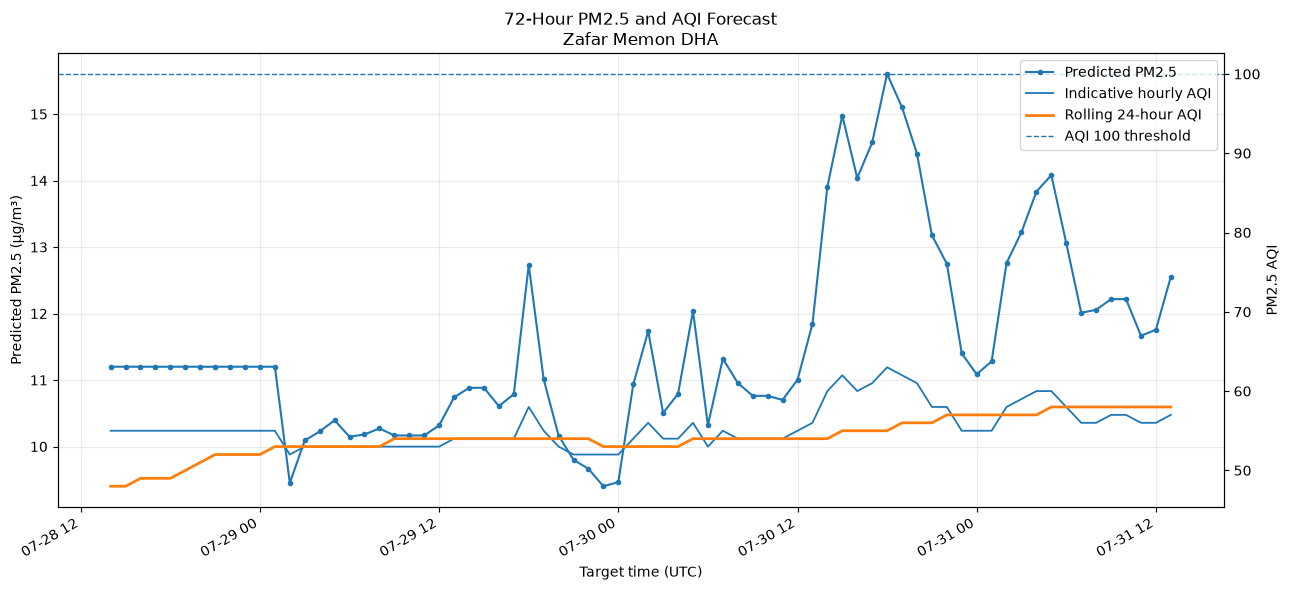

Saved AQI forecast plot: /home/riyan/Riyan/projects/pearls-aqi-predictor/aqi/runs/20260728T150612Z_aqi_d93945f7/aqi_forecast_plot.png


In [59]:
import matplotlib.pyplot as plt


figure, primary_axis = plt.subplots(
    figsize=(13, 6)
)

primary_axis.plot(
    phase_6_alerted_forecast_df[
        "target_time"
    ],
    phase_6_alerted_forecast_df[
        "predicted_pm25_ug_m3"
    ],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Predicted PM2.5",
)

primary_axis.set_xlabel(
    "Target time (UTC)"
)

primary_axis.set_ylabel(
    "Predicted PM2.5 (µg/m³)"
)

secondary_axis = (
    primary_axis.twinx()
)

secondary_axis.plot(
    phase_6_alerted_forecast_df[
        "target_time"
    ],
    phase_6_alerted_forecast_df[
        "indicative_hourly_pm25_aqi"
    ],
    linewidth=1.3,
    label="Indicative hourly AQI",
)

secondary_axis.plot(
    phase_6_alerted_forecast_df[
        "target_time"
    ],
    phase_6_alerted_forecast_df[
        "rolling_24h_pm25_aqi"
    ],
    linewidth=2,
    label="Rolling 24-hour AQI",
)

secondary_axis.axhline(
    100,
    linestyle="--",
    linewidth=1,
    label="AQI 100 threshold",
)

secondary_axis.set_ylabel(
    "PM2.5 AQI"
)

active_alert_df = (
    phase_6_alerted_forecast_df.loc[
        phase_6_alerted_forecast_df[
            "alert_is_active"
        ]
    ]
)

if not active_alert_df.empty:
    secondary_axis.scatter(
        active_alert_df["target_time"],
        active_alert_df[
            "alert_trigger_aqi"
        ],
        marker="x",
        label="Active alert",
    )

primary_axis.set_title(
    "72-Hour PM2.5 and AQI Forecast\n"
    + str(
        phase_6_alerted_forecast_df[
            "location_name"
        ].iloc[0]
    )
)

primary_axis.grid(
    alpha=0.25
)

primary_lines, primary_labels = (
    primary_axis.get_legend_handles_labels()
)

secondary_lines, secondary_labels = (
    secondary_axis.get_legend_handles_labels()
)

secondary_axis.legend(
    primary_lines + secondary_lines,
    primary_labels + secondary_labels,
    loc="upper right",
)

figure.autofmt_xdate()
figure.tight_layout()

figure.savefig(
    saved_aqi_run.plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved AQI forecast plot:",
    saved_aqi_run.plot_path,
)

In [60]:
saved_aqi_artifact_paths = {
    "AQI forecast": (
        saved_aqi_run.forecast_path
    ),
    "alert episodes": (
        saved_aqi_run.alert_episodes_path
    ),
    "forecast summary": (
        saved_aqi_run.summary_path
    ),
    "AQI metadata": (
        saved_aqi_run.metadata_path
    ),
    "validation report": (
        saved_aqi_run
        .validation_report_path
    ),
    "AQI plot": saved_aqi_run.plot_path,
}


saved_aqi_artifact_summary_df = (
    pd.DataFrame(
        [
            {
                "artifact": artifact_name,
                "exists": artifact_path.exists(),
                "size_bytes": (
                    artifact_path.stat().st_size
                    if artifact_path.exists()
                    else None
                ),
                "path": str(artifact_path),
            }
            for artifact_name, artifact_path
            in saved_aqi_artifact_paths.items()
        ]
    )
)

display(
    saved_aqi_artifact_summary_df
)

assert (
    saved_aqi_artifact_summary_df[
        "exists"
    ].all()
)

assert (
    saved_aqi_artifact_summary_df[
        "size_bytes"
    ].gt(0).all()
)

,artifact,exists,size_bytes,path
0,AQI forecast,True,34857,/home/riyan/Riyan/projects/pearls-aqi-predicto...
1,alert episodes,True,2,/home/riyan/Riyan/projects/pearls-aqi-predicto...
2,forecast summary,True,822,/home/riyan/Riyan/projects/pearls-aqi-predicto...
3,AQI metadata,True,2349,/home/riyan/Riyan/projects/pearls-aqi-predicto...
4,validation report,True,982,/home/riyan/Riyan/projects/pearls-aqi-predicto...
5,AQI plot,True,155337,/home/riyan/Riyan/projects/pearls-aqi-predicto...


In [61]:
reloaded_aqi_forecast_df = pd.read_parquet(
    saved_aqi_run.forecast_path
)

pd.testing.assert_frame_equal(
    phase_6_alerted_forecast_df.reset_index(
        drop=True
    ),
    reloaded_aqi_forecast_df.reset_index(
        drop=True
    ),
    check_dtype=True,
)

print(
    "Saved AQI forecast reloaded "
    "without data changes."
)

Saved AQI forecast reloaded without data changes.


In [62]:
publish_latest_aqi_run(
    saved_aqi_run
)

latest_output_files = sorted(
    [
        path.name
        for path
        in saved_aqi_run
        .latest_directory.iterdir()
        if path.is_file()
        and path.name != ".gitkeep"
    ]
)

print(
    "Latest AQI outputs:",
    latest_output_files,
)

Latest AQI outputs: ['alert_episodes.json', 'aqi_forecast_plot.png', 'aqi_forecast_summary.json', 'aqi_metadata.json', 'live_pm25_aqi_forecast.parquet', 'phase_6_validation_report.json']
